In [1]:
import os
import pickle
import sys
sys.path.append(os.path.join(os.getcwd(), "metient/jupyter_notebooks/lineage_tracing"))
import lineage_tracing_utilities as lt
import torch
import pandas as pd
import gzip
import networkx as nx
import seaborn as sns
from collections import Counter
import itertools
import matplotlib.pyplot as plt
from metient.util import plotting_util as putil

output_dir = "/data/morrisq/divyak/projects/metient/metient/jupyter_notebooks/lineage_tracing/outputs"


In [2]:
lt_dir = "/data/morrisq/divyak/projects/metient/metient/data/quinn_lt_2021/"
metient_results_dir = os.path.join(lt_dir, "metient_outputs", "2048bs_200runs_05202025")

with open(os.path.join(lt_dir,'cassiopeia_outputs/vanilla_greedy_cas_tissue_transitions.pkl'), 'rb') as f:
    quinn_tissue_trans_data = pickle.load(f)

clones = [int(f[:-len('_LL.pkl.gz')]) for f in os.listdir(metient_results_dir) if f.endswith('_LL.pkl.gz')]
clones = sorted(clones)
print(len(clones))

data = {
    "clone": [],
    "probability": [],
    "mig_pattern": [],
}

for clone in clones:
    print("\nClone", clone)
    with gzip.open(os.path.join(metient_results_dir,f"{clone}_LL.pkl.gz") ,"rb") as f:
        pckl = pickle.load(f)
    losses = pckl['losses']
    probs = putil.losses_to_probabilities(losses)
    _, _, _, mig_graphs = lt.extract_info(metient_results_dir, clone)
    for mig_graph,prob in zip(mig_graphs, probs):
        G = (mig_graph.fill_diagonal_(0) >= 1).float()
        non_zero_indices = G.nonzero()
        non_zero_indices_list = []
        for pair in non_zero_indices:
            non_zero_indices_list.append((int(pair[0]), int(pair[1])))
        data['clone'].append(clone)
        data['probability'].append(prob)
        data['mig_pattern'].append(tuple(non_zero_indices_list))

df = pd.DataFrame(data)
df


99

Clone 1
65 solutions


/lila/data/morrisq/divyak/projects/metient/metient/util/data_extraction_util.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  parents = torch.tensor(parents)[mask]



Clone 2
58 solutions

Clone 3
24 solutions

Clone 4
41 solutions

Clone 5
54 solutions

Clone 6
52 solutions

Clone 7
30 solutions

Clone 8
37 solutions

Clone 9
66 solutions

Clone 10
22 solutions

Clone 11
32 solutions

Clone 12
35 solutions

Clone 13
26 solutions

Clone 14
33 solutions

Clone 15
20 solutions

Clone 16
36 solutions

Clone 17
35 solutions

Clone 18
6 solutions

Clone 19
6 solutions

Clone 20
15 solutions

Clone 21
32 solutions

Clone 22
1 solutions

Clone 23
76 solutions

Clone 24
36 solutions

Clone 25
51 solutions

Clone 26
32 solutions

Clone 27
2 solutions

Clone 28
16 solutions

Clone 29
1 solutions

Clone 30
30 solutions

Clone 31
14 solutions

Clone 32
18 solutions

Clone 33
24 solutions

Clone 34
21 solutions

Clone 35
17 solutions

Clone 36
4 solutions

Clone 37
15 solutions

Clone 38
9 solutions

Clone 39
1 solutions

Clone 40
3 solutions

Clone 41
14 solutions

Clone 42
7 solutions

Clone 43
24 solutions

Clone 44
7 solutions

Clone 45
3 solutions

Clone 4

,clone,probability,mig_pattern
0,1,0.076,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0..."
1,1,0.022,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0..."
2,1,0.021,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0..."
3,1,0.021,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0..."
4,1,0.021,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0..."
...,...,...,...
1422,98,0.881,"((0, 4), (4, 1), (4, 2), (4, 3), (4, 5))"
1423,98,0.119,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5))"
1424,99,0.469,"((0, 4), (4, 1), (4, 2), (4, 3))"
1425,99,0.467,"((0, 1), (0, 2), (0, 3), (0, 4), (4, 2), (4, 3))"


In [3]:
# Count how many times each migration pattern appears for each clone
pattern_counts = df.groupby(['clone', 'mig_pattern']).size().reset_index(name='count')

# Filter to only show patterns that appear more than once for a clone
repeated_patterns = pattern_counts[pattern_counts['count'] > 1]

# Sort by clone and count
repeated_patterns = repeated_patterns.sort_values(['clone', 'count'], ascending=[True, False])

print("Migration patterns that appear multiple times for the same clone:")
print(repeated_patterns)


Migration patterns that appear multiple times for the same clone:
     clone                                        mig_pattern  count
1        1  ((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0...     23
29       1  ((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (2, 0...      3
5        1  ((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0...      2
41       2  ((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0...     11
42       2  ((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0...      5
..     ...                                                ...    ...
941     91   ((0, 1), (1, 2), (1, 3), (1, 4), (3, 4), (4, 3))      3
944     91   ((0, 2), (2, 1), (2, 3), (2, 4), (3, 4), (4, 3))      3
939     91           ((0, 1), (0, 2), (0, 3), (0, 4), (4, 3))      2
942     91           ((0, 1), (1, 2), (1, 3), (1, 4), (4, 3))      2
945     91           ((0, 2), (2, 1), (2, 3), (2, 4), (4, 3))      2

[190 rows x 3 columns]


In [4]:
import ast

df['mig_pattern'] = df['mig_pattern'].apply(lambda x: str(x))

# Step 1: Group by clone and mig_pattern to calculate the weighted sum of probabilities
weighted_avg_df = (df.groupby(['clone', 'mig_pattern'])
                    .agg(weighted_probability=('probability', 'sum'))
                    .reset_index())

# Step 2: For each clone, find the mig_pattern with the highest weighted probability
consensus_pattern_df = (weighted_avg_df.loc[weighted_avg_df.groupby('clone')['weighted_probability'].idxmax()]
                        .rename(columns={'mig_pattern': 'consensus_mig_pattern'}))

# Step 3: Return DataFrame with clone and the consensus migration pattern
consensus_pattern_df =  consensus_pattern_df[['clone', 'consensus_mig_pattern', 'weighted_probability']]
consensus_pattern_df['consensus_mig_pattern'] = consensus_pattern_df['consensus_mig_pattern'].apply(ast.literal_eval)


def count_shared_subgraphs(graphs, max_subgraph_size=30):
    subgraph_counter = Counter()

    # Iterate over each graph in the list of graphs
    for G in graphs:
        # Get the set of edges in the current graph
        edges = set(G.edges())

        # Generate subgraphs of size from 2 to max_subgraph_size
        for size in range(1, 6):
            # Generate all combinations of edges of the given size
            for edge_comb in itertools.combinations(edges, size):
                # Sort the edge combination to ensure consistency in key
                subgraph_counter[tuple(sorted(edge_comb))] += 1

    return subgraph_counter

all_graphs = []

all_edges = list(consensus_pattern_df['consensus_mig_pattern'])
for edge_list in all_edges:
    edge_list = [(lt.TISSUE_ORDER[edge[0]],lt.TISSUE_ORDER[edge[1]]) for edge in edge_list]
    G = nx.DiGraph()
    G.add_edges_from(edge_list)
    all_graphs.append(G)

# Count shared subgraphs
subgraph_counts = count_shared_subgraphs(all_graphs)
sorted_subgraph_counts = dict(sorted(subgraph_counts.items(), key=lambda x: x[1], reverse=True))

sorted_subgraph_counts

{(('LL', 'M1'),): 69,
 (('M1', 'M2'),): 66,
 (('LL', 'M1'), ('M1', 'M2')): 59,
 (('M1', 'RW'),): 52,
 (('M1', 'RE'),): 50,
 (('M1', 'M2'), ('M1', 'RW')): 48,
 (('LL', 'M1'), ('M1', 'RW')): 48,
 (('M1', 'Liv'),): 47,
 (('LL', 'M1'), ('M1', 'RE')): 46,
 (('M1', 'M2'), ('M1', 'RE')): 45,
 (('LL', 'M1'), ('M1', 'M2'), ('M1', 'RW')): 45,
 (('M1', 'Liv'), ('M1', 'M2')): 44,
 (('M1', 'RE'), ('M1', 'RW')): 44,
 (('LL', 'M1'), ('M1', 'Liv')): 43,
 (('LL', 'M1'), ('M1', 'M2'), ('M1', 'RE')): 42,
 (('M1', 'LL'),): 41,
 (('M1', 'Liv'), ('M1', 'RW')): 41,
 (('M1', 'Liv'), ('M1', 'RE')): 41,
 (('LL', 'M1'), ('M1', 'RE'), ('M1', 'RW')): 41,
 (('M1', 'LL'), ('M1', 'M2')): 40,
 (('LL', 'M1'), ('M1', 'LL')): 40,
 (('LL', 'M1'), ('M1', 'Liv'), ('M1', 'RW')): 40,
 (('LL', 'M1'), ('M1', 'Liv'), ('M1', 'M2')): 40,
 (('M1', 'M2'), ('M1', 'RE'), ('M1', 'RW')): 40,
 (('LL', 'M1'), ('M1', 'Liv'), ('M1', 'RE')): 39,
 (('LL', 'M1'), ('M1', 'LL'), ('M1', 'M2')): 39,
 (('M2', 'M1'),): 38,
 (('M1', 'Liv'), ('M1', 'M

In [5]:
consensus_pattern_df

,clone,consensus_mig_pattern,weighted_probability
1,1,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0...",0.483
41,2,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 0...",0.292
85,3,"((0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (4, 0...",0.444
130,4,"((0, 3), (0, 5), (1, 4), (2, 0), (2, 1), (2, 3...",0.095
166,5,"((0, 3), (0, 4), (2, 3), (2, 4), (3, 0), (3, 1...",0.099
...,...,...,...
959,95,"((0, 1), (0, 2), (0, 3), (0, 4))",1.000
960,96,"((0, 2),)",1.000
963,97,"((0, 4), (3, 1), (3, 2), (4, 3))",0.588
965,98,"((0, 4), (4, 1), (4, 2), (4, 3), (4, 5))",0.881


[["(('LL', 'M1'),)", 69.6969696969697], ["(('M1', 'M2'),)", 66.66666666666667], ["(('LL', 'M1'), ('M1', 'M2'))", 59.5959595959596], ["(('M1', 'RW'),)", 52.525252525252526], ["(('M1', 'RE'),)", 50.505050505050505], ["(('M1', 'M2'), ('M1', 'RW'))", 48.484848484848484]]


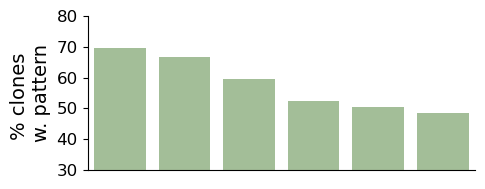

In [6]:

data = [[str(k),100*v/len(consensus_pattern_df)] for k,v in sorted_subgraph_counts.items()][:6]
print(data)
sorted_subgraph_df = pd.DataFrame(data,columns=['Sequential pattern', '% clones \nw. pattern'])
sorted_subgraph_df
fig, ax = plt.subplots(figsize=(5, 2))  # Adjust the size as needed
sns.barplot(x="Sequential pattern", y="% clones \nw. pattern", data=sorted_subgraph_df, color='#a1c492')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks([])
plt.yticks(fontsize=12)

plt.ylim(30,80)
plt.ylabel('% clones \nw. pattern', fontsize=14)
plt.xlabel('')
plt.savefig(os.path.join(output_dir,f"sequential pattern.png"), dpi=300, bbox_inches='tight',pad_inches=0.2)  # Save with tight bounding box

plt.show()
plt.close()

In [7]:
sorted_subgraph_counts

{(('LL', 'M1'),): 69,
 (('M1', 'M2'),): 66,
 (('LL', 'M1'), ('M1', 'M2')): 59,
 (('M1', 'RW'),): 52,
 (('M1', 'RE'),): 50,
 (('M1', 'M2'), ('M1', 'RW')): 48,
 (('LL', 'M1'), ('M1', 'RW')): 48,
 (('M1', 'Liv'),): 47,
 (('LL', 'M1'), ('M1', 'RE')): 46,
 (('M1', 'M2'), ('M1', 'RE')): 45,
 (('LL', 'M1'), ('M1', 'M2'), ('M1', 'RW')): 45,
 (('M1', 'Liv'), ('M1', 'M2')): 44,
 (('M1', 'RE'), ('M1', 'RW')): 44,
 (('LL', 'M1'), ('M1', 'Liv')): 43,
 (('LL', 'M1'), ('M1', 'M2'), ('M1', 'RE')): 42,
 (('M1', 'LL'),): 41,
 (('M1', 'Liv'), ('M1', 'RW')): 41,
 (('M1', 'Liv'), ('M1', 'RE')): 41,
 (('LL', 'M1'), ('M1', 'RE'), ('M1', 'RW')): 41,
 (('M1', 'LL'), ('M1', 'M2')): 40,
 (('LL', 'M1'), ('M1', 'LL')): 40,
 (('LL', 'M1'), ('M1', 'Liv'), ('M1', 'RW')): 40,
 (('LL', 'M1'), ('M1', 'Liv'), ('M1', 'M2')): 40,
 (('M1', 'M2'), ('M1', 'RE'), ('M1', 'RW')): 40,
 (('LL', 'M1'), ('M1', 'Liv'), ('M1', 'RE')): 39,
 (('LL', 'M1'), ('M1', 'LL'), ('M1', 'M2')): 39,
 (('M2', 'M1'),): 38,
 (('M1', 'Liv'), ('M1', 'M